# Aim
The purpose of this notebook is to show how to use JIT to tune a Stable Diffusion model.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2
%cd ../..
%pwd

In [ ]:
from aitune.torch.jit.patcher import patch_for_jit_tuning
from aitune.torch.jit.patched_module import PatchedModule
from aitune.torch.jit.config import config
import torch

from diffusers import StableDiffusionPipeline
from notebooks.jit.jit_commons import visualize_latency, benchmark
from PIL import Image

prompt = "A fluffy, orange tabby cat with bright green eyes is captured mid-air, pouncing playfully on a vibrant red ball of yarn"

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models
TensorRT-LLM is not installed. Please install TensorRT-LLM or set TRTLLM_PLUGINS_PATH to the directory containing libnvinfer_plugin_tensorrt_llm.so to use converters for torch.distributed ops


[08/05/2025-12:42:19] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


  from .autonotebook import tqdm as notebook_tqdm



# Stable Diffusion

Diffusion models have an internal diffusion loop. Hence it is important to set `min_samples` to a proper value. 
Otherwise, JIT won't see samples with different batch sizes and TRT backend will create static shapes.

In [3]:
config.dry_run = False
config.min_samples = 4
config.max_depth_level = 2
config.detect_graph_breaks = True

In [ ]:
@patch_for_jit_tuning
def create_model():
    pipe = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16)
    pipe.to("cuda")
    return pipe

In [5]:
pipe = create_model()

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 10.23it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  3.17it/s]
12:42:25.807 - INFO - ------------------------------------------------------------
12:42:25.808 - INFO - 🚀 Tuning graph `0` for module `CLIPTextModel 📊340.4M`:
12:42:25.808 - INFO -   number of parameters: 340.4M
12:42:25.809 - INFO -   number of layers: 1
12:42:25.809 - INFO -   precisions: torch.float16
12:42:25.809 - INFO -   graph_spec:
12:42:25.809 - INFO -     input_spec: ((input__0[dim0, 77] min_shape=[1, 77] max_shape=[2, 77] dtype=torch.int64,), {attention_mask: None})
12:42:25.809 - INFO -     output_spec: {last_hidden_state: output__0[dim0, 77, 1024] min_shape=[1, 77, 1024] max_shape=[2, 77, 1024] dtype=torch.float16, pooler_output: output__1[dim0, 1024] min_shape=[1, 1024] max_shape=[2, 1024] dtype=torch.float16}
12:42:25.809 - INFO -   num samples: 1
12:42:25.809 - INFO -   device: cuda
12:42:25.810 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/7562c594461aada2a8ad89ad746b5ffa829a62888e3d4796ddf9175f2ca2c26c/0
12:42:25.8

[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored


12:42:43.515 - Level 28 - [I] Finished engine building in 11.913 seconds
12:42:43.782 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/7562c594461aada2a8ad89ad746b5ffa829a62888e3d4796ddf9175f2ca2c26c/0/TensorRTBackend/af74c28a036db3019c5a3923d6c2511e1d3083af4ef6c8f99fea2628d19ad0f2/model.plan
12:42:44.426 - INFO -     ✅ backend built
12:42:44.434 - INFO -     ✅ backend validated
12:42:44.434 - INFO - 🎯 Strategy FirstWinsStrategy execution finished in 18.62s.
12:42:44.434 - INFO - ✅ Selected backend: TensorRTBackend(precision=fp16)


[08/05/2025-12:42:44] [TRT] [I] Loaded engine size: 653 MiB
[08/05/2025-12:42:44] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +2, now: CPU 0, GPU 651 (MiB)


...

12:46:53.963 - INFO - [I] Configuring with profiles:[
        Profile 0:
            {input__0 [min=(1, 4, 128, 128), opt=(2, 4, 128, 128), max=(2, 4, 128, 128)]}
    ]
12:46:53.964 - Level 22 - [I] Building engine with configuration:
    Flags                  | [FP16, TF32]
    Engine Capability      | EngineCapability.STANDARD
    Memory Pools           | [WORKSPACE: 48632.00 MiB, TACTIC_DRAM: 48632.00 MiB, TACTIC_SHARED_MEMORY: 1024.00 MiB]
    Tactic Sources         | [EDGE_MASK_CONVOLUTIONS, JIT_CONVOLUTIONS]
    Profiling Verbosity    | ProfilingVerbosity.DETAILED
    Preview Features       | [PROFILE_SHARING_0806]
12:46:55.426 - Level 28 - [I] Finished engine building in 1.462 seconds
12:46:55.429 - INFO - [I] Saving engine to /home/pbazan/.cache/aitune.jit/d71e485b2c44ba482fe6652211f33f2e113a7ce0051cdd04773fb5d67c88d978/0/TensorRTBackend/af74c28a036db3019c5a3923d6c2511e1d3083af4ef6c8f99fea2628d19ad0f2/model.plan
12:46:55.586 - INFO -     ✅ backend built
12:46:55.587 - INFO -  

[08/05/2025-12:46:55] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/05/2025-12:46:55] [TRT] [I] Loaded engine size: 0 MiB
[08/05/2025-12:46:55] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +1, now: CPU 0, GPU 3267 (MiB)


12:46:56.757 - INFO - ------------------------------------------------------------
12:46:56.758 - INFO - 🚀 Tuning graph `0` for module `Decoder 📊49.5M`:
12:46:56.758 - INFO -   number of parameters: 49.5M
12:46:56.758 - INFO -   number of layers: 6
12:46:56.759 - INFO -   precisions: torch.float16
12:46:56.759 - INFO -   graph_spec:
12:46:56.759 - INFO -     input_spec: ((input__0[dim0, 4, 128, 128] min_shape=[1, 4, 128, 128] max_shape=[2, 4, 128, 128] dtype=torch.float16,), {})
12:46:56.759 - INFO -     output_spec: output__0[dim0, 3, 1024, 1024] min_shape=[1, 3, 1024, 1024] max_shape=[2, 3, 1024, 1024] dtype=torch.float16
12:46:56.760 - INFO -   num samples: 1
12:46:56.760 - INFO -   device: cuda
12:46:56.760 - INFO -   cache_dir: /home/pbazan/.cache/aitune.jit/b36bb5cdfcac54c1bd35b49412fdc0a9095ec78ea69439c74bb3b530d23fcc51/0
12:46:56.760 - INFO -   strategy:
12:46:56.760 - INFO -     name: First Wins Strategy
12:46:56.760 - INFO -     description: evaluate backends in order, return

[08/05/2025-12:50:01] [TRT] [I] The logger passed into createInferRuntime differs from one already provided for an existing builder, runtime, or refitter. Uses of the global logger, returned by nvinfer1::getLogger(), will return the existing value.
[08/05/2025-12:50:01] [TRT] [I] Loaded engine size: 103 MiB
[08/05/2025-12:50:01] [TRT] [I] [MemUsageChange] TensorRT-managed allocation in IExecutionContext creation: CPU +0, GPU +5280, now: CPU 0, GPU 8642 (MiB)


100%|██████████| 1/1 [00:00<00:00,  5.93it/s]


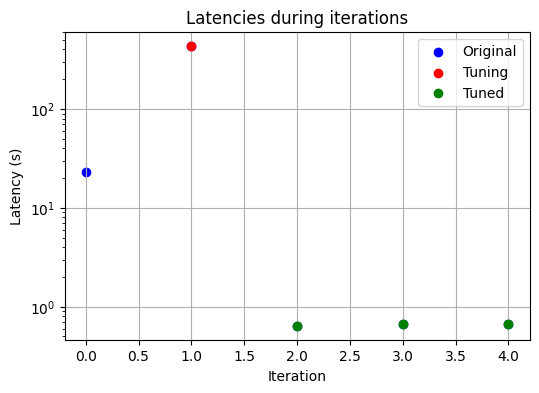

In [ ]:
def batch():
    with torch.no_grad():
        pipe([prompt] * 1, num_inference_steps=1, width=1024, height=1024)
        pipe([prompt] * 2, num_inference_steps=1, width=1024, height=1024)

visualize_latency(lambda: batch(), iterations=5)

In [7]:
PatchedModule.history

['New top module: CLIPTextModel 📊340.4M level=0🪜 state=init⏳ call_count=1',
 'New child module: CLIPTextTransformer 📊340.4M level=1🪜 state=init⏳ call_count=1',
 'New top module: UNet2DConditionModel 📊865.9M level=0🪜 state=init⏳ call_count=1',
 'New child module: TimestepEmbedding 📊2.1M level=1🪜 state=init⏳ call_count=1',
 'New child module: Conv2d 📊11.8K level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnDownBlock2D 📊10.9M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnDownBlock2D 📊37.5M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnDownBlock2D 📊141.3M level=1🪜 state=init⏳ call_count=1',
 'New child module: DownBlock2D 📊62.3M level=1🪜 state=init⏳ call_count=1',
 'New child module: UNetMidBlock2DCrossAttn 📊97.7M level=1🪜 state=init⏳ call_count=1',
 'New child module: UpBlock2D 📊162.2M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnUpBlock2D 📊260.3M level=1🪜 state=init⏳ call_count=1',
 'New child module: CrossAttnUpBloc

In [8]:
PatchedModule.print_hierarchy()

PatchedModule Hierarchy:
├─ CLIPTextModel 📊340.4M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
  ├─ CLIPTextTransformer 📊340.4M level=1🪜 state=detached☑️ call_count=4
├─ UNet2DConditionModel 📊865.9M level=0🪜 state=tuned🎯 (TensorRTBackend) call_count=4
  ├─ TimestepEmbedding 📊2.1M level=1🪜 state=detached☑️ call_count=4
  ├─ Conv2d 📊11.8K level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnDownBlock2D 📊10.9M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnDownBlock2D 📊37.5M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnDownBlock2D 📊141.3M level=1🪜 state=detached☑️ call_count=4
  ├─ DownBlock2D 📊62.3M level=1🪜 state=detached☑️ call_count=4
  ├─ UNetMidBlock2DCrossAttn 📊97.7M level=1🪜 state=detached☑️ call_count=4
  ├─ UpBlock2D 📊162.2M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnUpBlock2D 📊260.3M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnUpBlock2D 📊72.4M level=1🪜 state=detached☑️ call_count=4
  ├─ CrossAttnUpBlock2D 📊19.3M level=1🪜 state=detached☑️

# Benchmark

### JIT tuned pipeline

In [ ]:
benchmark(lambda: pipe([prompt], width=1024, height=1024), iterations=3)


  8%|▊         | 4/50 [00:00<00:03, 12.29it/s]

100%|██████████| 50/50 [00:04<00:00, 11.58it/s]


'4.44s ± 0.0197 (3 iterations)'

Check the image

In [10]:
resp = pipe([prompt], width=1024, height=1024)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:04<00:00, 11.58it/s]


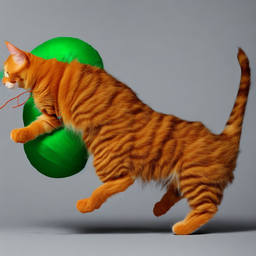

In [11]:
# resize image so that it does no take much space in notebook
img = resp["images"][0]
img_resized = img.resize((256, 256), Image.LANCZOS)
img_resized

### Original model

In [ ]:
pipe = StableDiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe.to("cuda");


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 14.07it/s]


In [ ]:
benchmark(lambda: pipe([prompt], width=1024, height=1024), iterations=3)


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:05<00:00,  9.24it/s]


'5.6s ± 0.02 (3 iterations)'